# 04 - CNN Metaparameters: Receptive Fields, $1 \times 1$ Convolutions & Dilations

This notebook investigates architectural metaparameter design choices in CNNs:

---

## Topics Covered:

1. **Receptive Field Math**: How kernel size and depth expand spatial context.
2. **$1 \times 1$ Convolutions (Network-in-Network / Bottleneck Blocks)**: Channel-wise projection & dimensionality reduction.
3. **Dilated (Atrous) Convolutions (`dilation` parameter)**: Expanding receptive field exponentially without adding parameters.
4. **Stride vs Pooling for Downsampling**: Strided conv (`stride=2`) vs MaxPool (`kernel_size=2`).
5. **Advanced Optimizers & Schedulers**: Comparing AdamW vs SGD + Momentum with `OneCycleLR`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as torch_optim

np.random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. $1 \times 1$ Convolutions (Channel Bottlenecks)

A $1 \times 1$ convolution computes linear combinations across feature channels at each spatial pixel:

- Reduces memory & computation (e.g. 128 channels $\rightarrow$ 32 channels).
- Introduces cross-channel non-linearity.


In [2]:
# Input tensor with 128 channels (batch=2, H=16, W=16)
x_large = torch.randn(2, 128, 16, 16)

# Bottleneck 1x1 Conv reducing channels from 128 -> 32
bottleneck_conv = nn.Conv2d(in_channels=128, out_channels=32, kernel_size=1)
x_bottleneck = bottleneck_conv(x_large)

print(f"Input Shape:      {list(x_large.shape)}")
print(f"Bottleneck Shape: {list(x_bottleneck.shape)}")
print(f"Parameters in 1x1 Conv: {bottleneck_conv.weight.numel():,}")
print(f"Parameters in equivalent 3x3 Conv: {nn.Conv2d(128, 32, 3, padding=1).weight.numel():,}")


Input Shape:      [2, 128, 16, 16]
Bottleneck Shape: [2, 32, 16, 16]
Parameters in 1x1 Conv: 4,096
Parameters in equivalent 3x3 Conv: 36,864


## 2. Dilated (Atrous) Convolutions (`dilation`)

Dilated convolutions insert spaces (holes) between kernel elements.
$$\text{Effective Kernel Size} = K + (K - 1) \times (d - 1)$$
where $d$ is the dilation rate. This expands the receptive field rapidly without increasing trainable parameters!


In [3]:
# Standard 3x3 Conv (Dilation = 1) -> Receptive Field = 3x3
conv_std = nn.Conv2d(1, 1, kernel_size=3, padding=1, dilation=1)

# Dilated 3x3 Conv (Dilation = 2) -> Receptive Field = 5x5
conv_dilated2 = nn.Conv2d(1, 1, kernel_size=3, padding=2, dilation=2)

# Dilated 3x3 Conv (Dilation = 4) -> Receptive Field = 9x9
conv_dilated4 = nn.Conv2d(1, 1, kernel_size=3, padding=4, dilation=4)

sample_in = torch.randn(1, 1, 32, 32)
print("Dilation=1 Output Shape:", list(conv_std(sample_in).shape))
print("Dilation=2 Output Shape:", list(conv_dilated2(sample_in).shape))
print("Dilation=4 Output Shape:", list(conv_dilated4(sample_in).shape))
print("Notice spatial resolution is preserved, but receptive field expanded exponentially!")


Dilation=1 Output Shape: [1, 1, 32, 32]
Dilation=2 Output Shape: [1, 1, 32, 32]
Dilation=4 Output Shape: [1, 1, 32, 32]
Notice spatial resolution is preserved, but receptive field expanded exponentially!


## 3. Strided Convolution vs Max Pooling

- **Max Pooling**: Non-parametric fixed rule ($2 \times 2$ max).
- **Strided Conv (`stride=2`)**: Learnable downsampling filter.


In [4]:
class StridedDownsampleBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        # Strided Convolution (stride=2 halves spatial dimensions)
        self.conv = nn.Conv2d(in_c, out_c, kernel_size=3, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_c)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

block = StridedDownsampleBlock(16, 32)
x_in = torch.randn(4, 16, 64, 64)
x_out = block(x_in)

print(f"Strided Downsample Input:  {list(x_in.shape)}")
print(f"Strided Downsample Output: {list(x_out.shape)}")


Strided Downsample Input:  [4, 16, 64, 64]
Strided Downsample Output: [4, 32, 32, 32]


## 4. CNN Learning Rate Scheduling: `OneCycleLR`

`OneCycleLR` warms up the learning rate to `max_lr` and then decays it following a cosine curve, enabling faster training convergence (Super-Convergence).


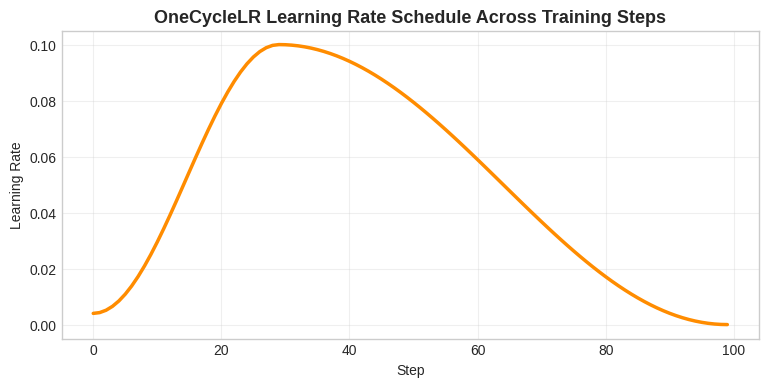

In [5]:
dummy_model = nn.Sequential(nn.Conv2d(3, 16, 3), nn.ReLU())
optimizer = torch_optim.SGD(dummy_model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch_optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=0.1, total_steps=100, pct_start=0.3
)

lrs = []
for step in range(100):
    lrs.append(scheduler.get_last_lr()[0])
    optimizer.step()
    scheduler.step()

plt.figure(figsize=(9, 4))
plt.plot(lrs, color='darkorange', linewidth=2.5)
plt.title('OneCycleLR Learning Rate Schedule Across Training Steps', fontsize=13, fontweight='bold')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)
plt.show()
